Example code for Fig. 9 (binned log-distance ratios v. redshift) for the TF DR1 paper

In [1]:
from astropy.io import fits
import astropy.constants as const

import numpy as np

import matplotlib.pyplot as plt

In [2]:
LightSpeed = const.c.to('km/s').value

# Data

In [3]:
hdul = fits.open('fig9_data.fits')

data = hdul[1].data
pv_lines = hdul[2].data
pv_labels = hdul[3].data

hdul.close()

# Plot

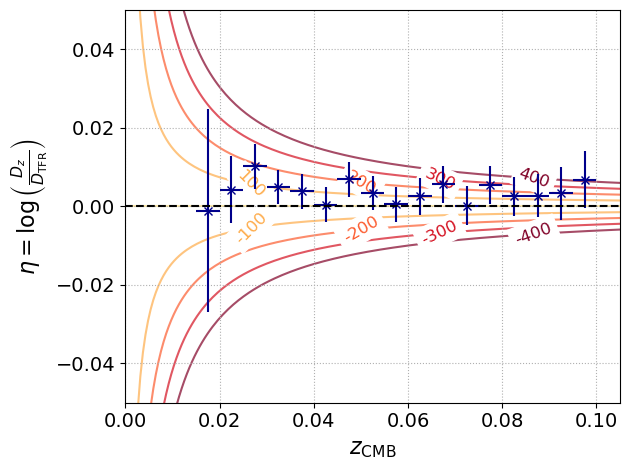

In [4]:
fig = plt.figure(tight_layout=True)

plt.errorbar(data['Z'], data['ETA'], xerr=data['DZ'], yerr=data['ETA_ERR'], fmt='x', color='darkblue')

#-------------------------------------------------------------------------------
colors = 0.8*np.fabs(pv_labels['V'])/np.amax(np.fabs(pv_labels['V'])) + 0.2

for v in range(len(pv_labels['V'])):
    c = plt.cm.YlOrRd(colors[v])

    plt.plot(pv_lines['Z'], pv_lines['ETA'][:,v], 
             color=c, 
             linestyle='-', 
             alpha=0.7, 
             zorder=0)

    if (v != 4):
        plt.text(pv_labels['X'][v]/LightSpeed, pv_labels['Y'][v], 
                 pv_labels['LABEL'][v], 
                 color=c, 
                 fontsize=12, 
                 rotation=pv_labels['ROT'][v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)
#-------------------------------------------------------------------------------
# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

plt.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.05, 0.05))
plt.xlim((0, 0.105));